In [2]:
from pathlib import Path
import urllib.request


data_path = Path("names.txt")
if not data_path.exists():
    url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
    urllib.request.urlretrieve(url, data_path)

words = data_path.read_text().splitlines()
print(f"Loaded {len(words)} names from {data_path}")

Loaded 32033 names from names.txt


In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
max(len(w) for w in words)


15

In [5]:
b={}
for w in words:
    chs= ['<S>']+list(w)+["<E>"]
    for ch1,ch2 in zip(chs,chs[1:]):
         biogram=(ch1,ch2)
         b[biogram]=b.get(biogram,0)+1


In [6]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [7]:
print(sorted(b.items(),key=lambda kv:-kv[1]))

[(('n', '<E>'), 6763), (('a', '<E>'), 6640), (('a', 'n'), 5438), (('<S>', 'a'), 4410), (('e', '<E>'), 3983), (('a', 'r'), 3264), (('e', 'l'), 3248), (('r', 'i'), 3033), (('n', 'a'), 2977), (('<S>', 'k'), 2963), (('l', 'e'), 2921), (('e', 'n'), 2675), (('l', 'a'), 2623), (('m', 'a'), 2590), (('<S>', 'm'), 2538), (('a', 'l'), 2528), (('i', '<E>'), 2489), (('l', 'i'), 2480), (('i', 'a'), 2445), (('<S>', 'j'), 2422), (('o', 'n'), 2411), (('h', '<E>'), 2409), (('r', 'a'), 2356), (('a', 'h'), 2332), (('h', 'a'), 2244), (('y', 'a'), 2143), (('i', 'n'), 2126), (('<S>', 's'), 2055), (('a', 'y'), 2050), (('y', '<E>'), 2007), (('e', 'r'), 1958), (('n', 'n'), 1906), (('y', 'n'), 1826), (('k', 'a'), 1731), (('n', 'i'), 1725), (('r', 'e'), 1697), (('<S>', 'd'), 1690), (('i', 'e'), 1653), (('a', 'i'), 1650), (('<S>', 'r'), 1639), (('a', 'm'), 1634), (('l', 'y'), 1588), (('<S>', 'l'), 1572), (('<S>', 'c'), 1542), (('<S>', 'e'), 1531), (('j', 'a'), 1473), (('r', '<E>'), 1377), (('n', 'e'), 1359), (('l'

In [8]:
import torch

In [9]:
N=torch.zeros((28,28),dtype=torch.int32)

In [10]:
alphabets=sorted(list(set(''.join(words))))
stringToIndex={s:i+1 for i,s in enumerate(alphabets)}
IndexToString={s+1:i for s,i in enumerate(alphabets)}
stringToIndex["."]=0
IndexToString[0]="."
IndexToString

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [11]:

for w in words:
    chs= ['.']+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        id1=stringToIndex[ch1]
        id2=stringToIndex[ch2]
        N[id1,id2]+=1


In [12]:
import matplotlib.pyplot as plt
%matplotlib inline


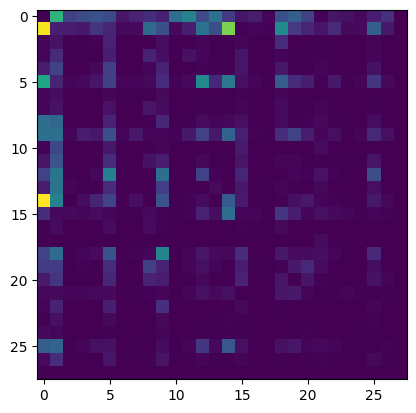

In [13]:
plt.imshow(N)

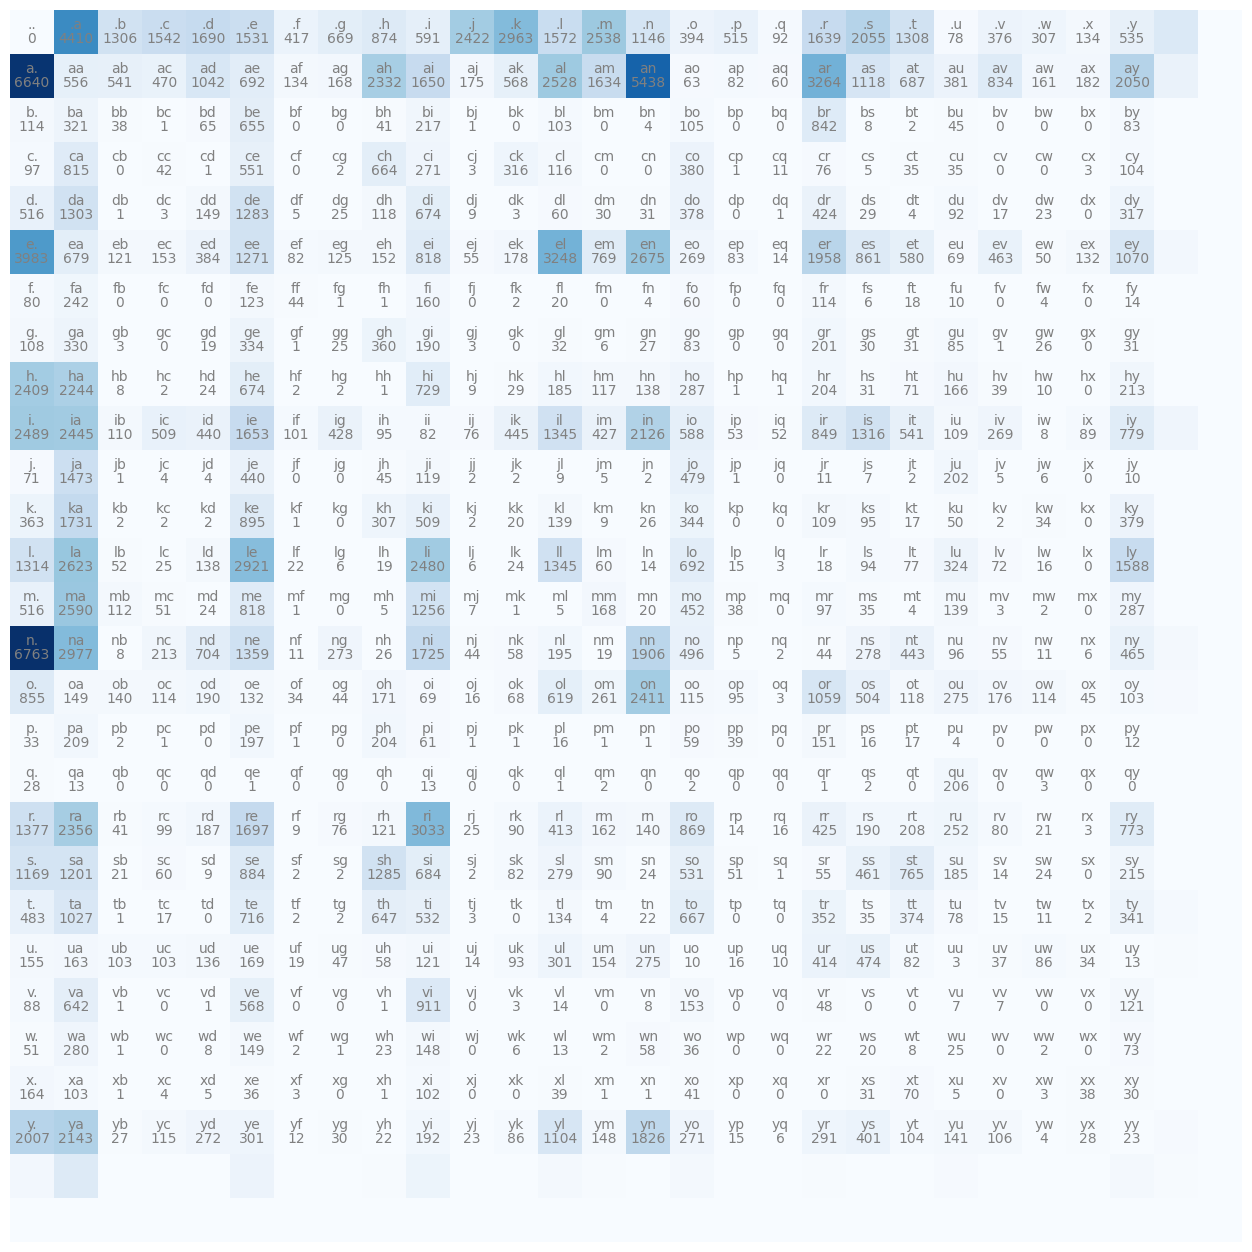

In [14]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
itos=IndexToString

for i in range(26):
    for j in range(26):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [15]:
# g = torch.Generator().manual_seed(123434324)

In [16]:
# index=torch.mtultinomial(p,num_samples=1,replacement=True,generator=g).item()

In [17]:
import torch

In [18]:
#word construction loop
g = torch.Generator().manual_seed(12344324)
for _ in range(5):
    out=[]
    ix=0
    while True:
        p=N[ix].float()
        p=p/p.sum()
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(IndexToString[ix])
        if ix==0:
            break
    print(''.join(out))
        


    


katreanviena.
anamyzyramaiajol.
aasoicuavitrorontinna.
riamamirisshwa.
jeshimae.


In [20]:

log_likelihood=0.0
for w in words[:3]:
    chs= ['.']+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        id1=stringToIndex[ch1]
        id2=stringToIndex[ch2]
        prob=N[id1,id2]/(N[id1].sum())
        log_likel=torch.log(prob)
        log_likelihood+=log_likel
        print(f"{ch1}{ch2} prob:{prob:.4f}")
print(f'logliklihood is {log_likelihood:.4f}')


.e prob:0.0478
em prob:0.0377
mm prob:0.0253
ma prob:0.3899
a. prob:0.1960
.o prob:0.0123
ol prob:0.0780
li prob:0.1777
iv prob:0.0152
vi prob:0.3541
ia prob:0.1381
a. prob:0.1960
.a prob:0.1377
av prob:0.0246
va prob:0.2495
a. prob:0.1960
logliklihood is -38.7856
